In [2]:
from functools import partial
import numpy as np
import jax
import jax.numpy as jnp
from jax import vmap, jit
from jax_grid import Grid
from jax_helpers import gg_space, glob_inh, sigmoid, softmax
from jax_scaffold import Scaffold
from tqdm import tqdm
import matplotlib.pyplot as plt
jax.config.update('jax_default_matmul_precision', 'highest')

# Grid only

In [3]:
exc_range = np.arange(0, 50, 1)
inh_range = np.arange(0, -50, -1)
lambdas = np.array([3,4,5])
Ng = np.sum(lambdas**2)

wggs = gg_space(Ng, lambdas, exc_range, inh_range, 'g2g_space.npy')
print('saved all weight matrices!')
print(wggs.shape)

saved all weight matrices!
(50, 50, 50, 50)


## Quadratic normalization

In [ ]:
lambdas = np.array([3, 4, 5])
lambdas_static = tuple(int(l) for l in lambdas)

g0_jax = jnp.asarray(Grid(lambdas, 'sigmoid', gg_exc=0, gg_inh=0).grid)

wggs = np.load('g2g_space.npy')                           # (100, 100, Ng, Ng)
wggs_flat = jnp.asarray(wggs).reshape(-1, *wggs.shape[-2:])  # (10000, Ng, Ng)

vmapped_run = jax.jit(
    jax.vmap(Grid.simulate_run, in_axes=(None, {'W_gg': 0}, None, None, None, None)),
    static_argnames=('lambdas', 'activation'),
)

def score_all(activation_fn, chunk_size=500):
    chunks = []
    for start in tqdm(range(0, wggs_flat.shape[0], chunk_size)):
        batch = wggs_flat[start:start + chunk_size]
        final = vmapped_run(g0_jax, {'W_gg': batch}, lambdas_static, 1.0, activation_fn, 0.1)
        correct = jnp.all(jnp.abs(final - g0_jax[None]) <= 1e-1, axis=1)  # (chunk, patts)
        chunks.append(np.asarray(jnp.mean(correct, axis=1)))
    return np.concatenate(chunks).reshape(len(exc_range), len(inh_range))

fracs_q  = score_all(glob_inh)

100%|██████████| 21/21 [10:25<00:00, 29.79s/it]


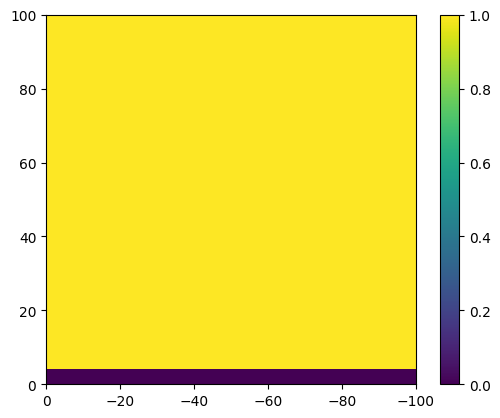

In [ ]:
plt.imshow(fracs_q, extent=[0, -100, 0, 100], origin='lower')
plt.colorbar()

In [ ]:
np.save('fracs_q.npy', fracs_q)

## Sigmoid

In [ ]:
lambdas = np.array([3, 4, 5])
lambdas_static = tuple(int(l) for l in lambdas)

g0_jax = jnp.asarray(Grid(lambdas, 'sigmoid', gg_exc=0, gg_inh=0).grid)
mean_g_norm = jnp.mean(jnp.linalg.norm(g0_jax, axis=0))

key = jax.random.PRNGKey(0)
noise_val = 1
noise = jax.random.normal(key, g0_jax.shape) / jnp.sqrt(Ng)
g0_noisy = g0_jax + noise_val * noise * mean_g_norm

wggs = np.load('g2g_space.npy')                           # (100, 100, Ng, Ng)
wggs_flat = jnp.asarray(wggs).reshape(-1, *wggs.shape[-2:])  # (10000, Ng, Ng)

vmapped_run = jax.jit(
    jax.vmap(Grid.simulate_run, in_axes=(None, {'W_gg': 0}, None, None, None, None)),
    static_argnames=('lambdas', 'activation'),
)

def score_all(activation_fn, chunk_size=100):
    chunks = []
    for start in tqdm(range(0, wggs_flat.shape[0], chunk_size)):
        batch = wggs_flat[start:start + chunk_size]
        final = vmapped_run(g0_noisy, {'W_gg': batch}, lambdas_static, 1.0, activation_fn, 0.01)
        correct = jnp.all(jnp.abs(final - g0_jax[None]) <= 1e-1, axis=1)  # (chunk, patts)
        chunks.append(np.asarray(jnp.mean(correct, axis=1)))
    return np.concatenate(chunks).reshape(len(exc_range), len(inh_range))
fracs_sig = score_all(sigmoid)

100%|██████████| 25/25 [03:28<00:00,  8.34s/it]


0.92861116 0.93666667


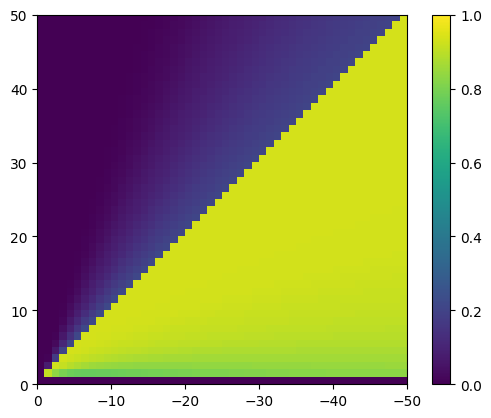

In [ ]:
plt.imshow(fracs_sig, extent=[0, -50, 0, 50], origin='lower', vmin=0, vmax=1)
plt.colorbar()
print(fracs_sig[5,8], fracs_sig[40, 40])

In [ ]:
np.save('fracs_sig.npy', fracs_sig)

## Softmax

In [ ]:
fracs_soft = score_all(softmax)

100%|██████████| 21/21 [12:45<00:00, 36.46s/it]


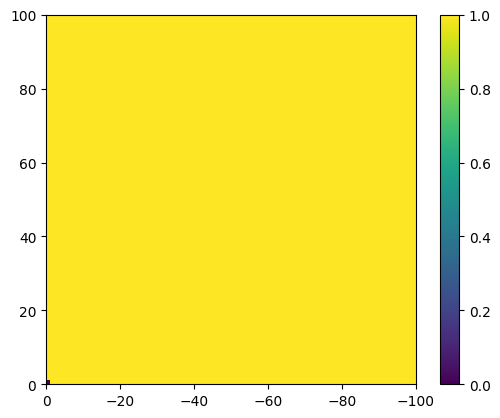

In [ ]:
plt.imshow(fracs_soft, extent=[0, -100, 0, 100], origin='lower')
plt.colorbar()

## Adding noise

In [ ]:
lambdas = np.array([3, 4, 5])
grid = Grid(lambdas, 'sigmoid', 40, -40)
g0_clean = jnp.asarray(grid.grid)

mean_g_norm = jnp.mean(jnp.linalg.norm(g0_clean, axis=0))

def make_noisy_batch(key, g0, noise_val, mean_norm, Ng, n_runs):
    keys = jax.random.split(key, n_runs)
    def one_run(k):
        noise = jax.random.normal(k, g0.shape) / jnp.sqrt(Ng)
        return g0 + noise_val * noise * mean_norm
    return jax.vmap(one_run)(keys)                          # (n_runs, Ng, patts_total)

vmapped_grid_run = jax.jit(
    jax.vmap(Grid.simulate_run, in_axes=(0, None, None, None, None, None)),
    static_argnames=('lambdas', 'activation'),
)

def noise_curve(scaffold, noise_vals, n_runs=5, key=jax.random.PRNGKey(0)):
    """Run the noise-robustness sweep for one Grid instance; returns mean/std frac_correct per noise_val."""
    g0_clean = jnp.asarray(scaffold.grid)
    mean_g_norm = jnp.mean(jnp.linalg.norm(g0_clean, axis=0))

    frac_correct = np.zeros((len(noise_vals), n_runs))
    for i, noise_val in enumerate(noise_vals):
        key, subkey = jax.random.split(key)
        g0_batch = make_noisy_batch(subkey, g0_clean, noise_val, mean_g_norm, scaffold.Ng, n_runs)

        final_batch = vmapped_grid_run(
            g0_batch, scaffold.weights, scaffold.lambdas, scaffold.tau_g, scaffold.activation, 0.01,
        )  # (n_runs, Ng, patts_total)

        err = jnp.max(jnp.abs(final_batch - g0_clean[None]), axis=1)
        frac_correct[i] = np.asarray(jnp.mean(err < 0.1, axis=1))

    return frac_correct.mean(axis=1), frac_correct.std(axis=1)

Varying i

In [ ]:
candidate_wggs = {
    'exc5_inh-1':   Grid(lambdas, 'sigmoid', 5, -1),
    'exc5_inh-3':   Grid(lambdas, 'sigmoid', 5, -3),
    'exc5_inh-5':  Grid(lambdas, 'sigmoid', 5, -5),
    'exc5_inh-7':  Grid(lambdas, 'sigmoid', 5, -7),
    'exc5_inh-9':  Grid(lambdas, 'sigmoid', 5, -9),
}

noise_vals = np.arange(0, 5, 0.5)
results = {}
for name, scaffold in candidate_wggs.items():
    results[name] = noise_curve(scaffold, noise_vals, n_runs=5)

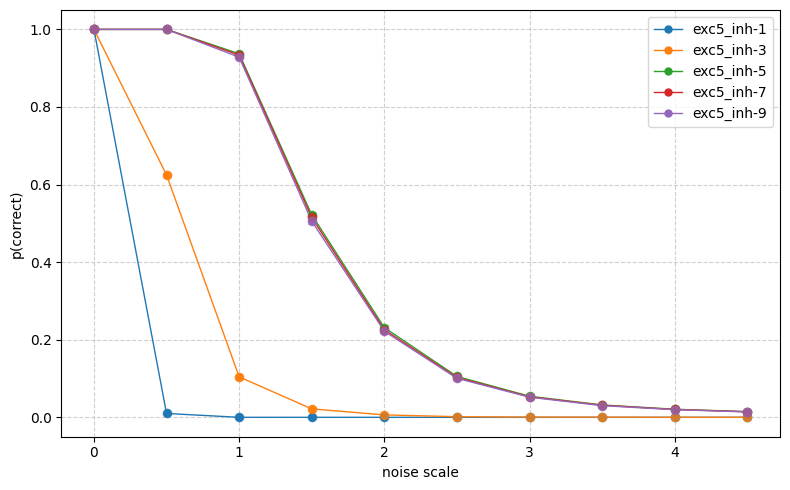

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for name, (mean_frac, std_frac) in results.items():
    line, = ax.plot(noise_vals, mean_frac, lw=1, marker='o', markersize=5, label=name)
    ax.errorbar(noise_vals, mean_frac, yerr=std_frac, fmt='o', capsize=3, color=line.get_color(), alpha=0.7)


ax.set_xlabel('noise scale')
ax.set_ylabel('p(correct)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Varying e


In [ ]:
candidate_wggs = {
    'exc1_inh-5':   Grid(lambdas, 'sigmoid', 1, -5),
    'exc3_inh-5':   Grid(lambdas, 'sigmoid', 3, -5),
    'exc5_inh-5':  Grid(lambdas, 'sigmoid', 5, -5),
    'exc7_inh-5':  Grid(lambdas, 'sigmoid', 7, -5),
    'exc9_inh-5':  Grid(lambdas, 'sigmoid', 9, -5),
}

noise_vals = np.arange(0, 5, 0.5)
results_1 = {}
for name, scaffold in candidate_wggs.items():
    results_1[name] = noise_curve(scaffold, noise_vals, n_runs=5)

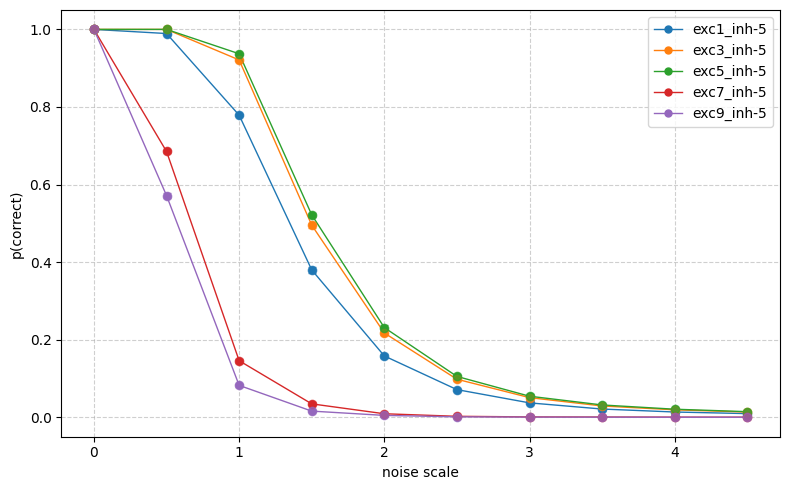

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, (mean_frac, std_frac) in results_1.items():
    line, = ax.plot(noise_vals, mean_frac, lw=1, marker='o', markersize=5, label=name)
    # add error bars
    ax.errorbar(noise_vals, mean_frac, yerr=std_frac, fmt='o', capsize=3, color=line.get_color(), alpha=0.7)


ax.set_xlabel('noise scale')
ax.set_ylabel('p(correct)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## plotting trajectories

In [ ]:
lambdas = np.array([3, 4, 5])
e, i = 9, -5
grid = Grid(lambdas, 'sigmoid', e, i)
g0 = jnp.asarray(grid.grid)
noise_val = 1

mean_g_norm = jnp.mean(jnp.linalg.norm(g0, axis=0))
key = jax.random.PRNGKey(0)
noise = jax.random.normal(key, g0.shape) / jnp.sqrt(grid.Ng)
g0_noisy = g0 + noise_val * noise * mean_g_norm

g_traj = grid.simulate_run_traj(g0_noisy, grid.weights, grid.lambdas, grid.tau_g, grid.activation, grid.dt)

0.08583333333333333
(3600,)
774 1.0000006
(array([   0,    1,    2, ..., 3597, 3598, 3599]),)
original state: 8 9 14
2 9 14


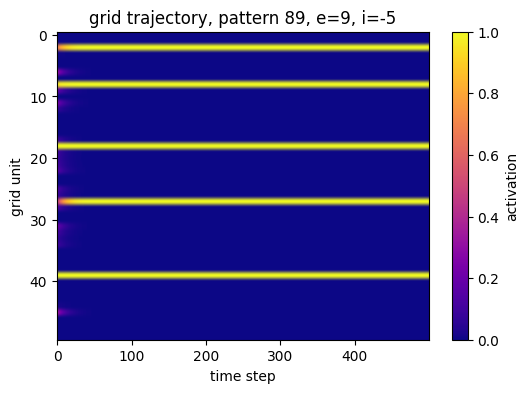

In [ ]:
g_err = np.max(np.abs(g_traj[-1, :, :] - g0), axis=0)
frac_grid_sig = np.mean(g_err < 0.2, axis=-1)
print(frac_grid_sig)
print(g_err.shape)
print(np.argmax(g_err), np.max(g_err))

#patt = np.argmax(g_err)
print(np.where(g_err > 0.2))
patt = 89
print("original state:", np.argmax(g0[:,patt][:9]), np.argmax(g0[:,patt][9:25]), np.argmax(g0[:,patt][25:]))
print(np.argmax(g_traj[-1, :, patt][:9]), np.argmax(g_traj[-1, :, patt][9:25]), np.argmax(g_traj[-1, :, patt][25:]))

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(np.asarray(g_traj[:, :, patt]).T, aspect='auto', origin='upper', cmap='plasma', vmin=0, vmax=1)
ax.set_xlabel('time step')
ax.set_ylabel('grid unit')
ax.set_title(f'grid trajectory, pattern {patt}, e={e}, i={i}')
fig.colorbar(im, label='activation')
plt.show()

# Scaffold

In [4]:
@partial(jax.jit, static_argnames=('lambdas', 'activation'))
def run_and_score_chunk(g0, h0, g_true, weights, lambdas, b, tau_g, tau_h, activation, dt, h0_norm):
    final_g, final_h = jax.vmap(
        Scaffold.simulate_run,
        in_axes=(None, None, {'W_gg': 0, 'W_gh': None, 'W_hg': None}, None, None, None, None, None, None),
    )(g0, h0, weights, lambdas, b, tau_g, tau_h, activation, dt)

    grid_err = jnp.max(jnp.abs(final_g - g_true[None]), axis=1)
    hc_err   = jnp.linalg.norm(final_h - h0[None], axis=1) / h0_norm[None]
    return grid_err, hc_err

## Sigmoid

In [10]:
lambdas = np.array([3, 4, 5])
lambdas_static = tuple(int(l) for l in lambdas)
scaffold = Scaffold(400, lambdas, 'sigmoid', gg_exc=0, gg_inh=0, gamma=0.6, dt=0.0075)

g0_jax = jnp.zeros_like(scaffold.grid[:, :])
g_true_jax = jnp.asarray(scaffold.grid[:, :])
h0_jax = jnp.asarray(scaffold.hc[:, :])
h0_norm   = jnp.linalg.norm(h0_jax, axis=0)

wggs = np.load('g2g_space.npy')                              # (100, 100, Ng, Ng)
wggs_flat = jnp.asarray(wggs).reshape(-1, *wggs.shape[-2:])  # (10000, Ng, Ng)

def score_scaffold(activation_fn, chunk_size=200):
    grid_chunks, hc_chunks = [], []
    for start in tqdm(range(0, wggs_flat.shape[0], chunk_size)):
        batch = wggs_flat[start:start + chunk_size]
        weights_batch = {'W_gg': batch, 'W_gh': scaffold.weights['W_gh'], 'W_hg': scaffold.weights['W_hg']}

        grid_err, hc_err = run_and_score_chunk(
            g0_jax, h0_jax, g_true_jax, weights_batch, lambdas_static,
            scaffold.b, scaffold.tau_g, scaffold.tau_h, activation_fn, scaffold.dt, h0_norm,
        )
        grid_chunks.append(np.asarray(grid_err))
        hc_chunks.append(np.asarray(hc_err))

    grid_errors = np.concatenate(grid_chunks).reshape(len(exc_range), len(inh_range), -1)
    hc_errors   = np.concatenate(hc_chunks).reshape(len(exc_range), len(inh_range), -1)
    return grid_errors, hc_errors


g_errs, h_errs  = score_scaffold(sigmoid)


100%|██████████| 13/13 [05:53<00:00, 27.22s/it]


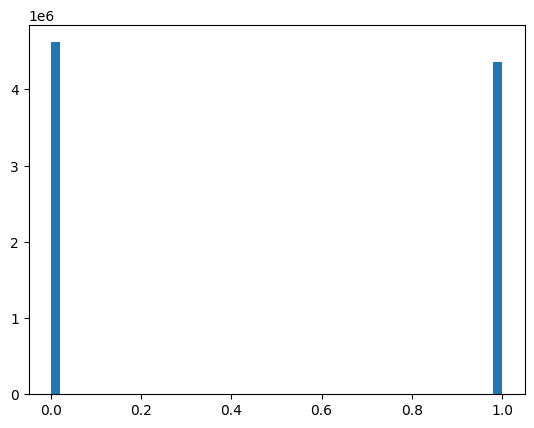

In [11]:
plt.hist(g_errs.ravel(), bins=50)
plt.show()

In [44]:
np.save('scaff_sig_g_dt001.npy', g_errs)
np.save('scaff_sig_h_dt001.npy', h_errs)

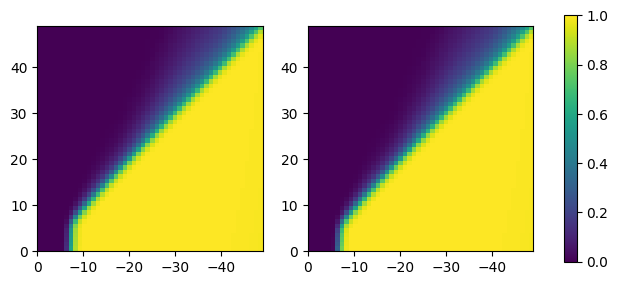

In [12]:
grid_thresh, hc_thresh = 0.3, 0.5

frac_grid_sig = np.mean(g_errs < grid_thresh, axis=-1)
frac_hc_sig   = np.mean(h_errs < hc_thresh, axis=-1)


fig, ax = plt.subplots(1, 2, figsize=(8,8))
ax[0].imshow(frac_grid_sig, extent=[inh_range[0], inh_range[-1], exc_range[0], exc_range[-1]], origin='lower', vmin=0, vmax=1)
im = ax[1].imshow(frac_hc_sig, extent=[inh_range[0], inh_range[-1], exc_range[0], exc_range[-1]], origin='lower', vmin=0, vmax=1)
cbar = fig.colorbar(im, ax=ax, shrink=0.4, pad=0.05)

In [28]:
max_idx_flat_grid = np.argmax(frac_grid_sig)
row_idx_grid, col_idx_grid = np.unravel_index(max_idx_flat_grid, frac_grid_sig.shape)

max_idx_flat_hc = np.argmax(frac_hc_sig)
row_idx_hc, col_idx_hc = np.unravel_index(max_idx_flat_hc, frac_hc_sig.shape)

print(f"Max frac_grid_sig at flattened index: {max_idx_flat_grid}, 2D indices: ({row_idx_grid}, {col_idx_grid})")
print(f"Corresponding exc_range value for grid: {exc_range[row_idx_grid]}, inh_range value for grid: {inh_range[col_idx_grid]}")

print(f"Max frac_hc_sig at flattened index: {max_idx_flat_hc}, 2D indices: ({row_idx_hc}, {col_idx_hc})")
print(f"Corresponding exc_range value for hc: {exc_range[row_idx_hc]}, inh_range value for hc: {inh_range[col_idx_hc]}")

Max frac_grid_sig at flattened index: 734, 2D indices: (18, 14)
Corresponding exc_range value for grid: 4.5, inh_range value for grid: -8.5
Max frac_hc_sig at flattened index: 734, 2D indices: (18, 14)
Corresponding exc_range value for hc: 4.5, inh_range value for hc: -8.5


## Quadratic normalization

In [ ]:
lambdas = np.array([3, 4, 5])
lambdas_static = tuple(int(l) for l in lambdas)
scaffold = Scaffold(400, lambdas, 'sigmoid', gg_exc=0, gg_inh=0, gamma=0.6)

g0_jax = jnp.zeros_like(scaffold.grid)
h0_jax = jnp.asarray(scaffold.hc)
h0_norm   = jnp.linalg.norm(h0_jax, axis=0)

wggs = np.load('g2g_space.npy')                              # (100, 100, Ng, Ng)
wggs_flat = jnp.asarray(wggs).reshape(-1, *wggs.shape[-2:])  # (10000, Ng, Ng)

def score_scaffold(activation_fn, chunk_size=200):
    grid_chunks, hc_chunks = [], []
    for start in tqdm(range(0, wggs_flat.shape[0], chunk_size)):
        batch = wggs_flat[start:start + chunk_size]
        weights_batch = {'W_gg': batch, 'W_gh': scaffold.weights['W_gh'], 'W_hg': scaffold.weights['W_hg']}

        grid_err, hc_err = run_and_score_chunk(
            g0_jax, h0_jax, weights_batch, lambdas_static,
            scaffold.b, scaffold.tau_g, scaffold.tau_h, activation_fn, scaffold.dt, h0_norm,
        )
        grid_chunks.append(np.asarray(grid_err))  # pulls to host RAM, frees GPU mem for next chunk
        hc_chunks.append(np.asarray(hc_err))

    grid_errors = np.concatenate(grid_chunks).reshape(len(exc_range), len(inh_range), -1)
    hc_errors   = np.concatenate(hc_chunks).reshape(len(exc_range), len(inh_range), -1)
    return grid_errors, hc_errors

g_errs_q, h_errs_q  = score_scaffold(glob_inh)

100%|██████████| 52/52 [37:41<00:00, 43.49s/it]


In [ ]:
np.save('scaff_q_g.npy', g_errs_q)
np.save('scaff_q_h.npy', h_errs_q)

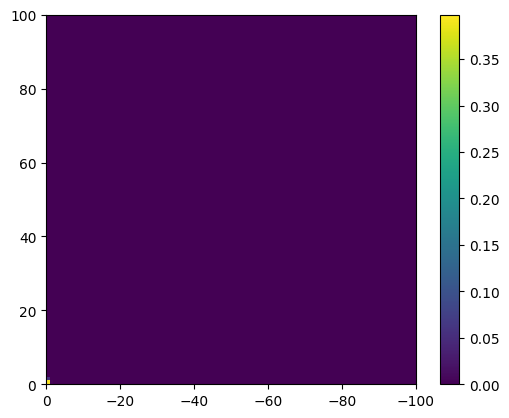

In [ ]:
grid_thresh, hc_thresh = 0.1, 0.01

frac_grid_q = np.mean(g_errs_q < grid_thresh, axis=-1)
frac_hc_q   = np.mean(h_errs_q < hc_thresh, axis=-1)
plt.imshow(frac_grid_q, extent=[0, -100, 0, 100], origin='lower')
plt.colorbar()

## Softmax

In [ ]:
g_errs_soft, h_errs_soft  = score_scaffold(softmax)

100%|██████████| 52/52 [38:08<00:00, 44.00s/it]


In [ ]:
np.save('scaff_soft_g.npy', g_errs_soft)
np.save('scaff_soft_h.npy', h_errs_soft)

## plotting trajectories

In [ ]:
lambdas = np.array([3,4,5])
e, i = 5, -8.75
scaffold = Scaffold(400, lambdas, 'sigmoid', e, i, gamma=0.6)
h0 = scaffold.hc
g0 = jnp.zeros_like(scaffold.grid)
g_true = scaffold.grid
g_traj, _ = scaffold.simulate_run_sampled(g0, h0, scaffold.weights,
                                          scaffold.lambdas, scaffold.b, scaffold.tau_g, scaffold.tau_h,
                                          scaffold.activation)

0.5475
original state: 2 6 13
1 6 13


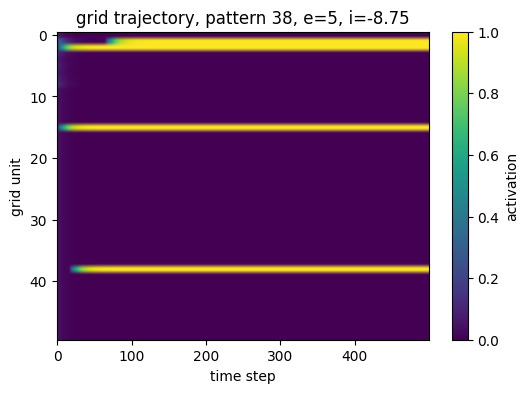

In [ ]:
g_err = np.max(np.abs(g_traj[-1, :, :] - g_true), axis=0)
frac_grid_sig = np.mean(g_err < 0.2, axis=-1)
print(frac_grid_sig)

#patt = np.argmax(g_err)

patt = 38
print("original state:", np.argmax(g_true[:,patt][:9]), np.argmax(g_true[:,patt][9:25]), np.argmax(g_true[:,patt][25:]))
print(np.argmax(g_traj[-1, :, patt][:9]), np.argmax(g_traj[-1, :, patt][9:25]), np.argmax(g_traj[-1, :, patt][25:]))

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(np.asarray(g_traj[:, :, patt]).T, aspect='auto', origin='upper', cmap='viridis', vmin=0, vmax=1)
ax.set_xlabel('time step')
ax.set_ylabel('grid unit')
ax.set_title(f'grid trajectory, pattern {patt}, e={e}, i={i}')
fig.colorbar(im, label='activation')
plt.show()

In [ ]:
where = np.where(g_err > 0.2)
incorrect = g_traj[-1, :, where[0]]
print(incorrect.shape[0])
incorrect_sum = np.sum(incorrect, axis=1)
not_unique = np.where(incorrect_sum > 3.2)
print(len(not_unique[0]))
print(not_unique)
print(incorrect_sum[9])

1529
68
(array([   9,   38,   60,   69,   72,  132,  141,  193,  219,  225,  232,
        272,  316,  340,  344,  348,  357,  404,  407,  462,  466,  470,
        524,  558,  586,  623,  647,  677,  678,  702,  706,  731,  740,
        767,  773,  792,  798,  851,  858,  862,  890,  894,  908,  918,
        928,  957,  987, 1033, 1046, 1081, 1093, 1142, 1153, 1170, 1202,
       1261, 1282, 1299, 1322, 1327, 1333, 1382, 1384, 1390, 1395, 1421,
       1459, 1502]),)
3.9999988


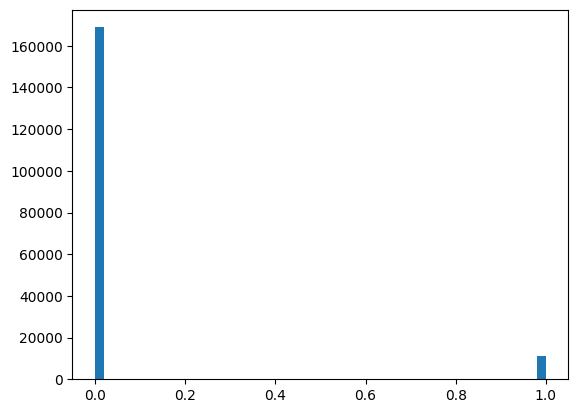

In [ ]:
plt.hist(g_traj[-1, :, :].ravel(), bins=50)
plt.show()

## Classifying failure modes

In [51]:
def classify_failure_modes(g_final_batch, g_target, lambdas, active_thresh=0.5, err_thresh=0.2):
    """
    g_final_batch: (n_weights, Ng, patts_total)
    g_target:      (Ng, patts_total)
    Returns two boolean arrays, shape (n_weights, patts_total):
      wrong_winner : converged to a clean one-hot-per-module state, but the wrong unit
      multi_winner : at least one module has 0 or >1 active units (didn't cleanly converge)
    """
    lambda_sq = np.array([l*l for l in lambdas])
    jumps = np.concatenate([[0], np.cumsum(lambda_sq)])[:-1]

    g_err = np.max(np.abs(g_final_batch - g_target[None]), axis=1)   # (n_weights, patts)
    incorrect_mask = g_err > err_thresh

    n_weights, Ng, n_patts = g_final_batch.shape
    n_active_per_module = np.zeros((n_weights, len(lambdas), n_patts), dtype=int)

    for m, (lam, start) in enumerate(zip(lambdas, jumps)):
        size = lam * lam
        module_activity = g_final_batch[:, start:start+size, :]      # (n_weights, size, patts)
        n_active_per_module[:, m, :] = np.sum(module_activity > active_thresh, axis=1)

    all_modules_one_hot = np.all(n_active_per_module == 1, axis=1)   # (n_weights, patts) -- checks EACH module, not a pooled total

    wrong_winner = incorrect_mask & all_modules_one_hot
    multi_winner = incorrect_mask & ~all_modules_one_hot
    return wrong_winner, multi_winner

def score_and_classify(scaffold, candidate_wggs, g0_init, h0, g0_target,
                        activation_fn=sigmoid, active_thresh=0.5, err_thresh=0.2):
    """
    candidate_wggs:  dict[name] -> W_gg array, shape (Ng, Ng)
    Returns a dict[name] -> {'frac_correct', 'n_wrong_winner', 'n_multi_winner', 'g_final'}
    """
    names = list(candidate_wggs.keys())
    W_gg_batch = jnp.stack([jnp.asarray(candidate_wggs[n]) for n in names])  # (n_candidates, Ng, Ng)

    weights = {
        'W_gg': W_gg_batch,
        'W_gh': scaffold.weights['W_gh'],
        'W_hg': scaffold.weights['W_hg'],
    }

    vmapped_run = jax.jit(
        jax.vmap(
            Scaffold.simulate_run,
            in_axes=(None, None, {'W_gg': 0, 'W_gh': None, 'W_hg': None}, None, None, None, None, None, None),
        ),
        static_argnames=('lambdas', 'activation'),
    )

    final_g, final_h = vmapped_run(
        g0_init, h0, weights, scaffold.lambdas,
        scaffold.b, scaffold.tau_g, scaffold.tau_h, activation_fn, scaffold.dt,
    )
    g_final_np = np.asarray(final_g)  # (n_candidates, Ng, patts_total)
    g_target_np = np.asarray(g0_target)

    wrong, multi = classify_failure_modes(
        g_final_np, g_target_np, scaffold.lambdas, active_thresh, err_thresh
    )
    g_err = np.max(np.abs(g_final_np - g_target_np[None]), axis=1)
    correct = g_err <= err_thresh

    results = {}
    for i, name in enumerate(names):
        results[name] = {
            'frac_correct': correct[i].mean(),
            'n_wrong_winner': int(wrong[i].sum()),
            'n_multi_winner': int(multi[i].sum()),
            'g_final': g_final_np[i],
        }
    return results

def make_wgg(lambdas, Ng, exc, inh):
    W = np.zeros((Ng, Ng))
    i = 0
    for lam in lambdas:
        size = lam**2
        W[i:i+size, i:i+size] = inh
        i += size
    np.fill_diagonal(W, exc)
    return W

def score_and_classify_grid(lambdas, candidate_wggs, g0_init, g0_target,
                             activation_fn, tau_g=1.0, dt=0.1,
                             active_thresh=0.5, err_thresh=0.2):

    lambdas_static = tuple(int(l) for l in lambdas)
    names = list(candidate_wggs.keys())
    W_gg_batch = jnp.stack([jnp.asarray(candidate_wggs[n]) for n in names])  # (n_candidates, Ng, Ng)

    weights = {'W_gg': W_gg_batch}

    vmapped_run = jax.jit(
        jax.vmap(
            Grid.simulate_run,
            in_axes=(None, {'W_gg': 0}, None, None, None, None),
        ),
        static_argnames=('lambdas', 'activation'),
    )

    final_g = vmapped_run(g0_init, weights, lambdas_static, tau_g, activation_fn, dt)
    g_final_np = np.asarray(final_g)     # (n_candidates, Ng, patts_total)
    g_target_np = np.asarray(g0_target)

    wrong, multi = classify_failure_modes(
        g_final_np, g_target_np, lambdas, active_thresh, err_thresh
    )
    g_err = np.max(np.abs(g_final_np - g_target_np[None]), axis=1)
    correct = g_err <= err_thresh

    results = {}
    for i, name in enumerate(names):
        results[name] = {
            'frac_correct': correct[i].mean(),
            'n_wrong_winner': int(wrong[i].sum()),
            'n_multi_winner': int(multi[i].sum()),
            'g_final': g_final_np[i],
        }
    return results

def plot_failure_modes(results):
  import pandas as pd

  data = {
      'model': list(results.keys()),
      'wrong_winner': [r['n_wrong_winner'] for r in results.values()],
      'multi_winner': [r['n_multi_winner'] for r in results.values()]
  }

  df_failures = pd.DataFrame(data)

  fig, ax = plt.subplots(figsize=(10, 6))
  x_values = np.arange(len(df_failures['model']))

  ax.plot(x_values, df_failures['wrong_winner'], marker='o', linestyle='-', label='Wrong Winner', color='skyblue')
  ax.plot(x_values, df_failures['multi_winner'], marker='o', linestyle='-', label='Multi Winner', color='lightcoral')

  ax.set_xlabel('Model')
  ax.set_ylabel('Number of Failures')
  ax.set_title('Comparison of Failure Modes Across Models')
  ax.set_xticks(x_values)
  ax.set_xticklabels(df_failures['model'], rotation=45, ha='right')
  ax.legend()
  ax.grid(True, linestyle='--', alpha=0.7)
  plt.tight_layout()
  plt.show()

### Scaffold

exc4_inh-8: frac_correct=0.918, wrong_winner=5, multi_winner=290
exc5_inh-8: frac_correct=0.861, wrong_winner=4, multi_winner=498
exc6_inh-8: frac_correct=0.720, wrong_winner=2, multi_winner=1007
exc7_inh-8: frac_correct=0.515, wrong_winner=1, multi_winner=1746
exc8_inh-8: frac_correct=0.289, wrong_winner=1, multi_winner=2559
exc9_inh-8: frac_correct=0.155, wrong_winner=0, multi_winner=3041
exc10_inh-8: frac_correct=0.076, wrong_winner=0, multi_winner=3326


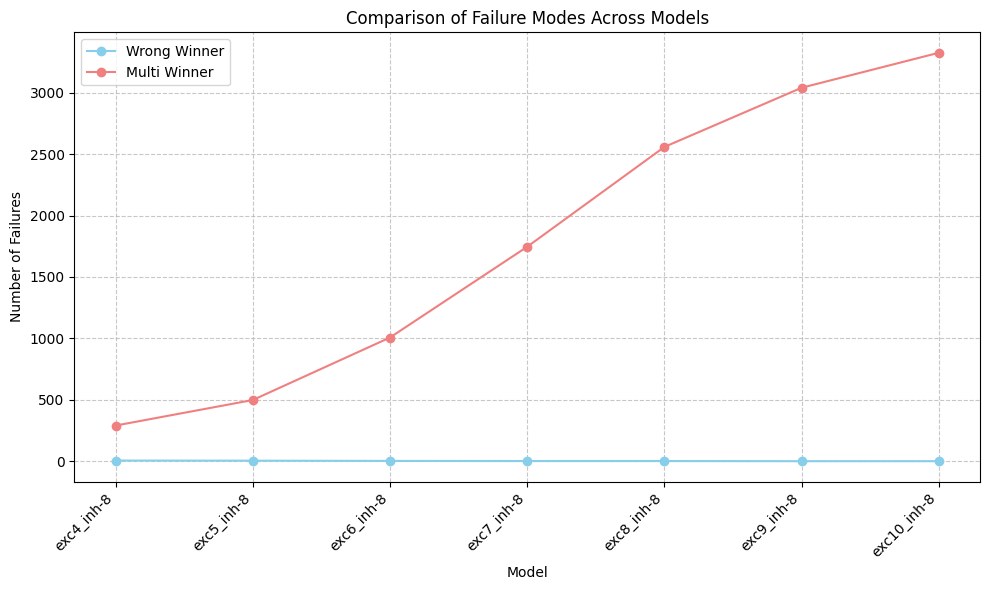

In [62]:
lambdas = np.array([3, 4, 5])
scaffold = Scaffold(400, lambdas, 'sigmoid', gg_exc=4, gg_inh=-1, gamma=0.6)

g0_target = jnp.asarray(scaffold.grid)
h0 = jnp.asarray(scaffold.hc)
g0_init = jnp.zeros_like(g0_target)
Ng = scaffold.Ng
candidate_wggs = {
    'exc4_inh-8':  make_wgg(lambdas, Ng, 4, -8),
    'exc5_inh-8':  make_wgg(lambdas, Ng, 5, -8),
    'exc6_inh-8':  make_wgg(lambdas, Ng, 6, -8),
    'exc7_inh-8':  make_wgg(lambdas, Ng, 7, -8),
    'exc8_inh-8':  make_wgg(lambdas, Ng, 8, -8),
    'exc9_inh-8':  make_wgg(lambdas, Ng, 9, -8),
    'exc10_inh-8':  make_wgg(lambdas, Ng, 10, -8),
}

results = score_and_classify(scaffold, candidate_wggs, g0_init, h0, g0_target)
for name, r in results.items():
    print(f"{name}: frac_correct={r['frac_correct']:.3f}, "
          f"wrong_winner={r['n_wrong_winner']}, multi_winner={r['n_multi_winner']}")
plot_failure_modes(results)

### Grid

exc1_inh-5: frac_correct=0.774, wrong_winner=141, multi_winner=672
exc3_inh-5: frac_correct=0.916, wrong_winner=210, multi_winner=92
exc5_inh-5: frac_correct=0.936, wrong_winner=226, multi_winner=5
exc7_inh-5: frac_correct=0.161, wrong_winner=38, multi_winner=2984
exc9_inh-5: frac_correct=0.086, wrong_winner=20, multi_winner=3271


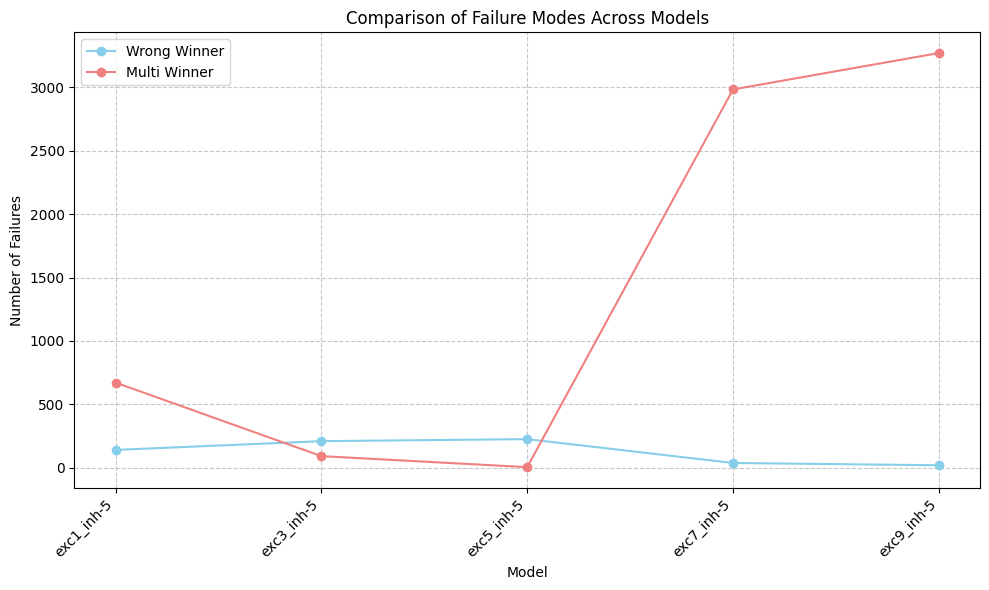

In [ ]:
lambdas = np.array([3, 4, 5])
grid = Grid(lambdas, 'sigmoid', 4, -1)   # only used here to get Ng and the clean grid patterns
Ng = grid.Ng
g0_target = jnp.asarray(grid.grid)

noise_val = 1
mean_g_norm = jnp.mean(jnp.linalg.norm(g0_target, axis=0))
key = jax.random.PRNGKey(0)
noise = jax.random.normal(key, g0_target.shape) / jnp.sqrt(Ng)
g0_noisy = g0_target + noise_val * noise * mean_g_norm

candidate_wggs = {
    'exc1_inh-5':  make_wgg(lambdas, Ng, 1, -5),
    'exc3_inh-5':  make_wgg(lambdas, Ng, 3, -5),
    'exc5_inh-5':  make_wgg(lambdas, Ng, 5, -5),
    'exc7_inh-5':  make_wgg(lambdas, Ng, 7, -5),
    'exc9_inh-5':  make_wgg(lambdas, Ng, 9, -5),
}

results_g = score_and_classify_grid(lambdas, candidate_wggs, g0_noisy, g0_target, sigmoid)
for name, r in results_g.items():
    print(f"{name}: frac_correct={r['frac_correct']:.3f}, "
          f"wrong_winner={r['n_wrong_winner']}, multi_winner={r['n_multi_winner']}")
plot_failure_modes(results_g)

exc5_inh-1: frac_correct=0.000, wrong_winner=0, multi_winner=3600
exc5_inh-3: frac_correct=0.112, wrong_winner=24, multi_winner=3174
exc5_inh-5: frac_correct=0.936, wrong_winner=226, multi_winner=5
exc5_inh-7: frac_correct=0.931, wrong_winner=221, multi_winner=27
exc5_inh-9: frac_correct=0.925, wrong_winner=213, multi_winner=56


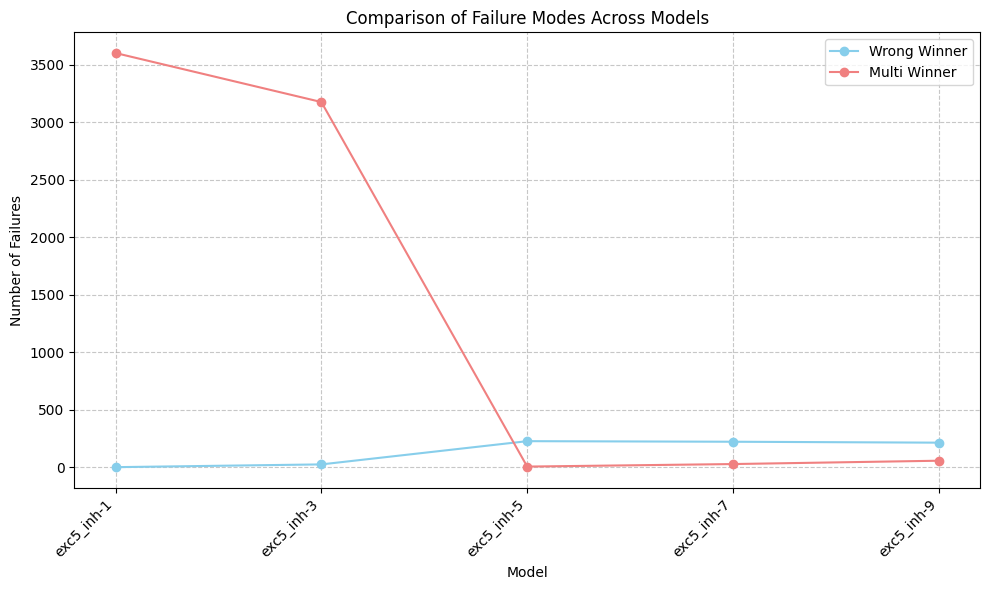

In [ ]:
candidate_wggs = {
    'exc5_inh-1':  make_wgg(lambdas, Ng, 5, -1),
    'exc5_inh-3':  make_wgg(lambdas, Ng, 5, -3),
    'exc5_inh-5':  make_wgg(lambdas, Ng, 5, -5),
    'exc5_inh-7':  make_wgg(lambdas, Ng, 5, -7),
    'exc5_inh-9':  make_wgg(lambdas, Ng, 5, -9),
}

results_g1 = score_and_classify_grid(lambdas, candidate_wggs, g0_noisy, g0_target, sigmoid)
for name, r in results_g1.items():
    print(f"{name}: frac_correct={r['frac_correct']:.3f}, "
          f"wrong_winner={r['n_wrong_winner']}, multi_winner={r['n_multi_winner']}")

plot_failure_modes(results_g1)

##